In [1]:
import pandas as pd
import numpy as np 

df_classic_emb = pd.read_csv('/users/framunno/res_iono/evaluation_metrics_multiscale_classic_emb_new_data_high.csv')
df_classic_emb_no_mean = pd.read_csv('/users/framunno/res_iono/evaluation_metrics_multiscale_classic_emb_nomean_new_data_high.csv')
df_adaptive_emb = pd.read_csv('/users/framunno/res_iono/evaluation_metrics_multiscale_adaptive_emb_new_data_high.csv')
df_multiscale = pd.read_csv('/users/framunno/res_iono/evaluation_metrics_multiscale_emb_v2_new_data_high.csv')
df_nocond = pd.read_csv('/users/framunno/res_iono/evaluation_metrics_nocond_new_data_high.csv')

In [13]:
df_classic_emb.columns

Index(['PSNR', 'SSIM', 'Physics_RelL2', 'Physics_NRMSE', 'Physics_MeanError',
       'Physics_StdRatio', 'CPCP_AbsError_Exact', 'CPCP_RelError_Exact',
       'CPCP_AbsError_P99', 'CPCP_RelError_P99', 'CPCP_AbsError_Smooth',
       'CPCP_RelError_Smooth', 'PS_LogMSE', 'PS_LogRelL2',
       'PS_RelErrorFiltered'],
      dtype='object')

In [2]:
import numpy as np
import ast

def postprocess_df(df, metrics):
    global_means = {}
    global_stds = {}

    for metric in metrics:
        all_chunks = []

        for string_data in df[metric]:
            values = np.array(ast.literal_eval(string_data))  # (300,)
            chunks = values.reshape(15, 20)                  # (15, 20)
            all_chunks.append(chunks)

        all_chunks = np.stack(all_chunks)  # (N, 15, 20)

        # ---- law of total variance ----
        mean_per_file = all_chunks.mean(axis=2)      # (N, 15)
        global_means[metric] = mean_per_file.mean(axis=0)

        variance_within = (all_chunks.std(axis=2) ** 2).mean(axis=0)
        variance_between = mean_per_file.var(axis=0)

        global_stds[metric] = np.sqrt(variance_within + variance_between)

        print(metric, all_chunks.shape)

    return global_means, global_stds


In [3]:
metrics = [
    # Image quality
    "PSNR",
    "SSIM",

    # Physics domain
    "Physics_RelL2",
    "Physics_NRMSE",
    "Physics_MeanError",
    "Physics_StdRatio",

    # CPCP
    "CPCP_AbsError_Exact",
    "CPCP_RelError_Exact",
    "CPCP_AbsError_P99",
    "CPCP_RelError_P99",
    "CPCP_AbsError_Smooth",
    "CPCP_RelError_Smooth",

    # Power spectrum
    "PS_LogMSE",
    "PS_LogRelL2",
    "PS_RelErrorFiltered",
]

means_classic, stds_classic = postprocess_df(df_classic_emb, metrics)
means_classic_nm, stds_classic_nm = postprocess_df(df_classic_emb_no_mean, metrics)
means_adaptive, stds_adaptive = postprocess_df(df_adaptive_emb, metrics)
means_multiscale, stds_multiscale = postprocess_df(df_multiscale, metrics)
means_nocond, stds_nocond = postprocess_df(df_nocond, metrics)


PSNR (175, 15, 20)
SSIM (175, 15, 20)
Physics_RelL2 (175, 15, 20)
Physics_NRMSE (175, 15, 20)
Physics_MeanError (175, 15, 20)
Physics_StdRatio (175, 15, 20)
CPCP_AbsError_Exact (175, 15, 20)
CPCP_RelError_Exact (175, 15, 20)
CPCP_AbsError_P99 (175, 15, 20)
CPCP_RelError_P99 (175, 15, 20)
CPCP_AbsError_Smooth (175, 15, 20)
CPCP_RelError_Smooth (175, 15, 20)
PS_LogMSE (175, 15, 20)
PS_LogRelL2 (175, 15, 20)
PS_RelErrorFiltered (175, 15, 20)
PSNR (175, 15, 20)
SSIM (175, 15, 20)
Physics_RelL2 (175, 15, 20)
Physics_NRMSE (175, 15, 20)
Physics_MeanError (175, 15, 20)
Physics_StdRatio (175, 15, 20)
CPCP_AbsError_Exact (175, 15, 20)
CPCP_RelError_Exact (175, 15, 20)
CPCP_AbsError_P99 (175, 15, 20)
CPCP_RelError_P99 (175, 15, 20)
CPCP_AbsError_Smooth (175, 15, 20)
CPCP_RelError_Smooth (175, 15, 20)
PS_LogMSE (175, 15, 20)
PS_LogRelL2 (175, 15, 20)
PS_RelErrorFiltered (175, 15, 20)
PSNR (175, 15, 20)
SSIM (175, 15, 20)
Physics_RelL2 (175, 15, 20)
Physics_NRMSE (175, 15, 20)
Physics_MeanError (1

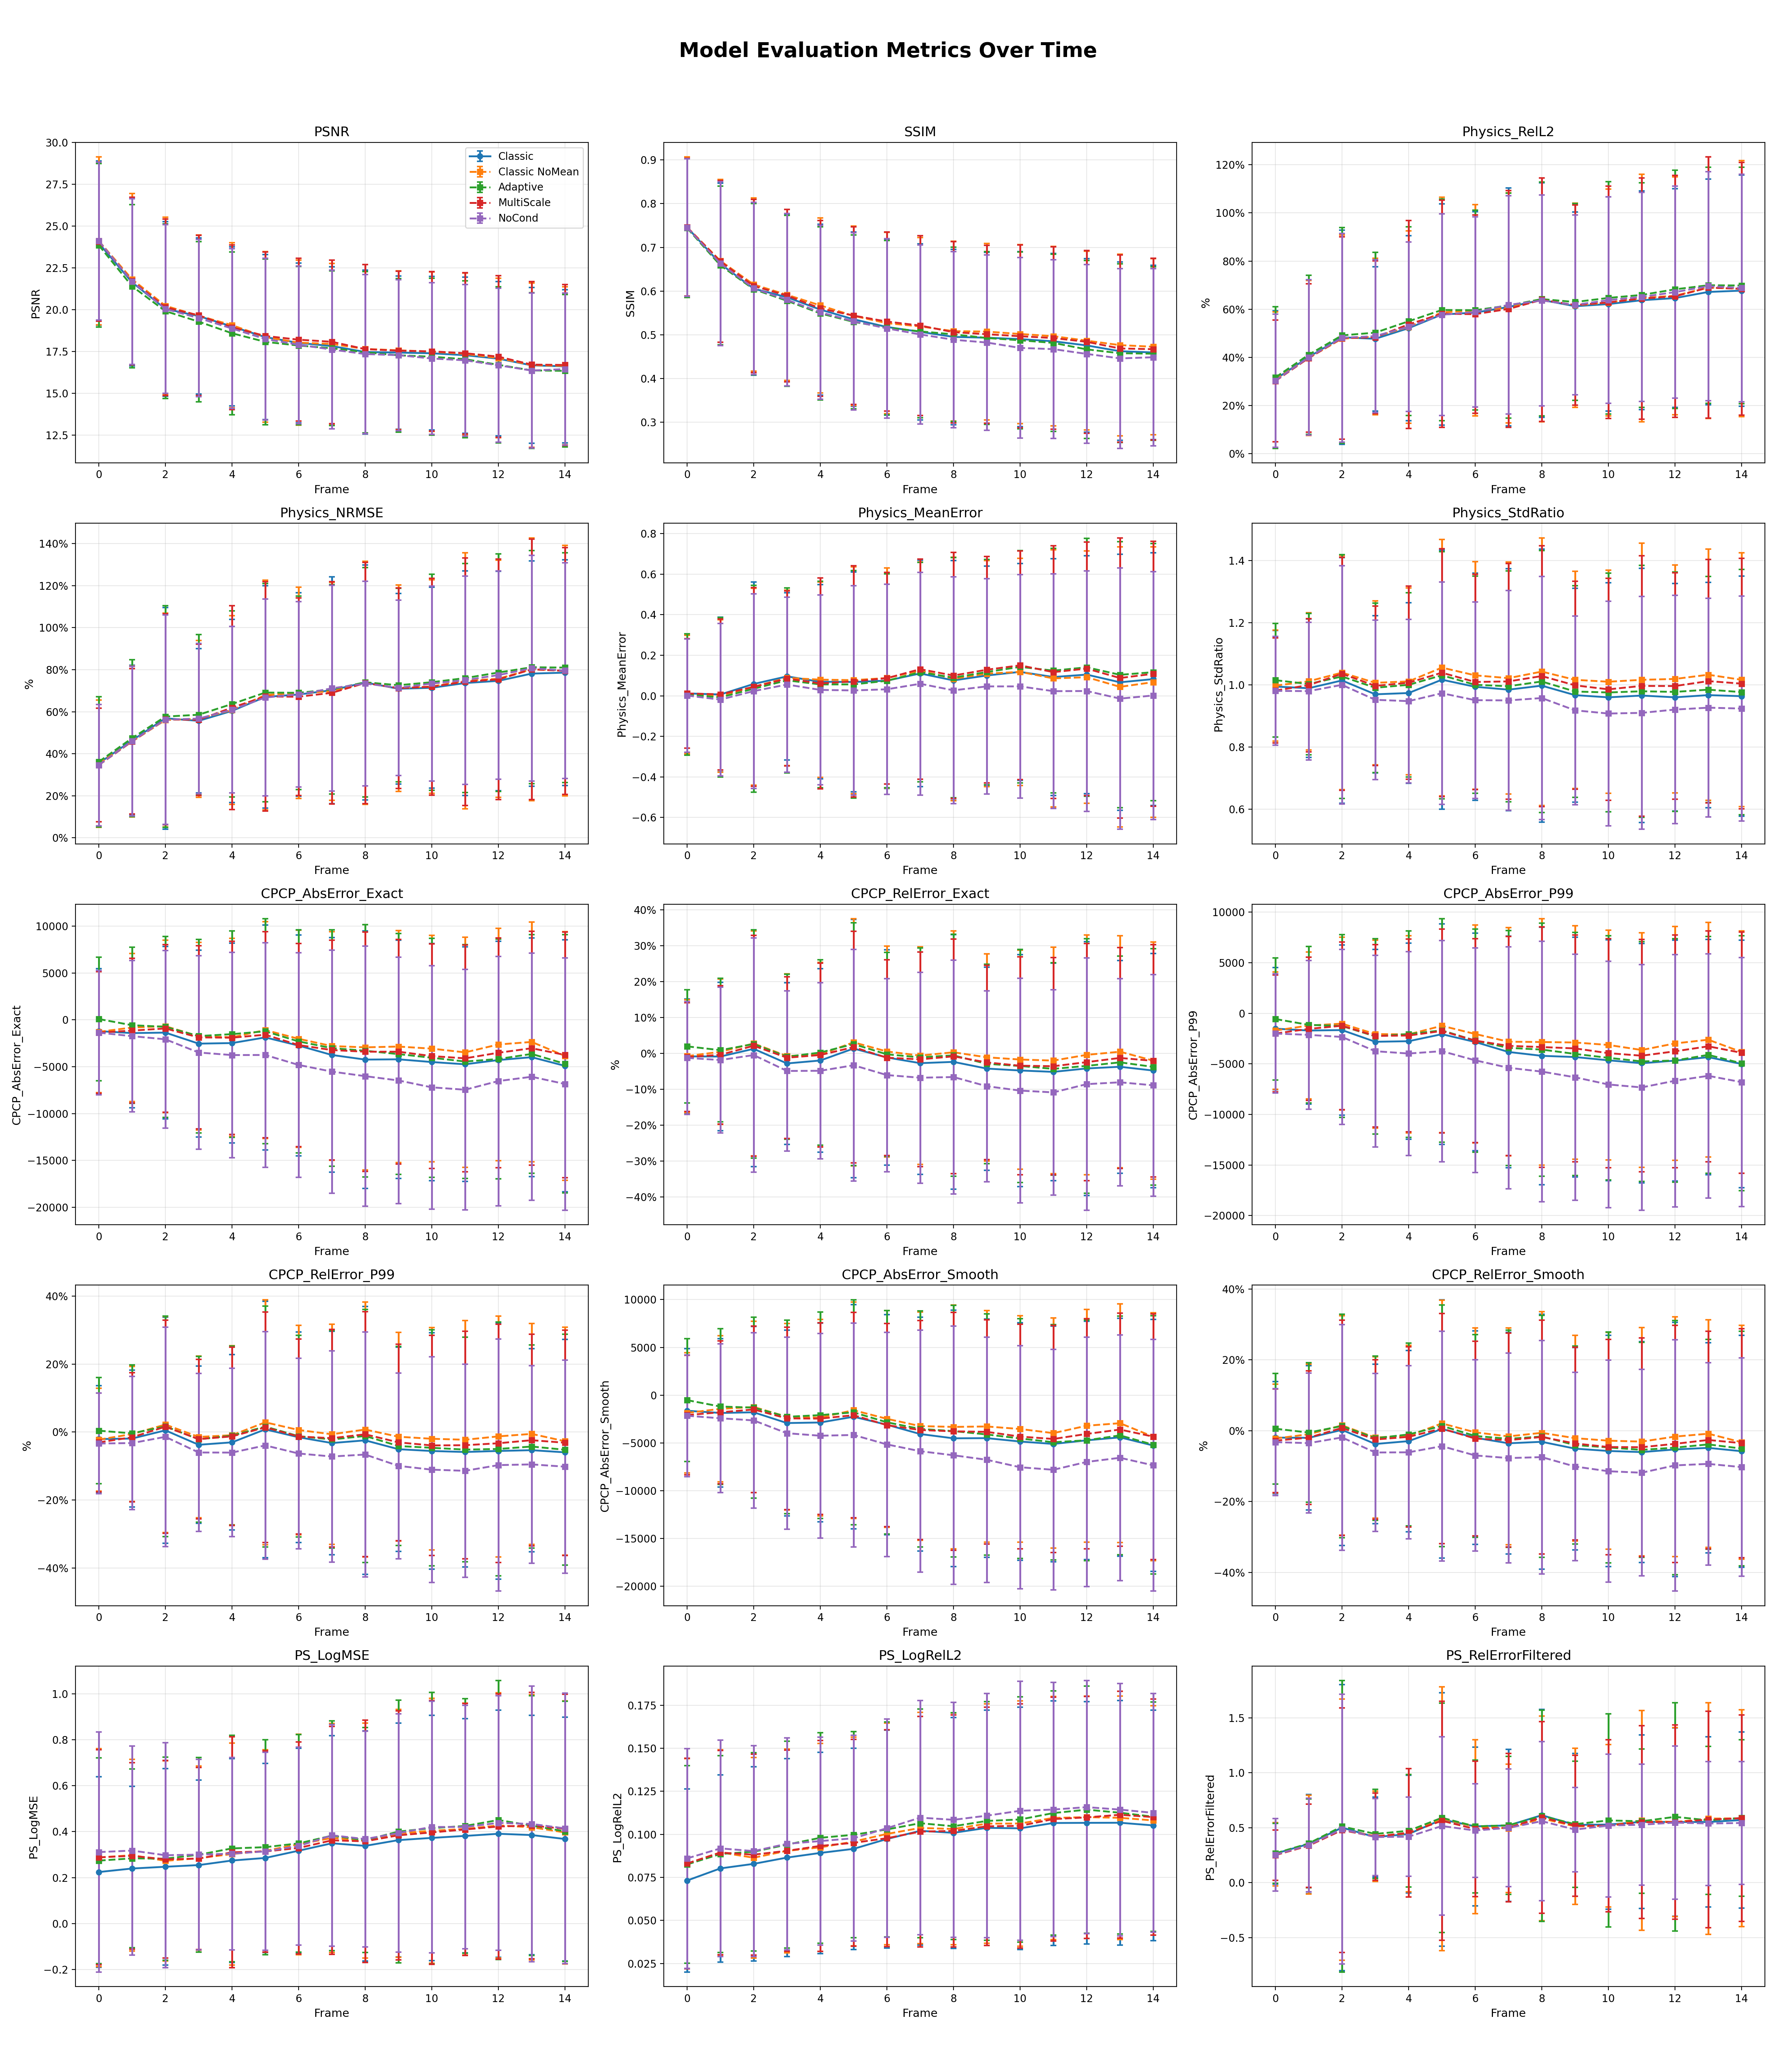

In [16]:
import numpy as np
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from PIL import Image

# ---- Figure setup ----
fig, axes = plt.subplots(5, 3, figsize=(24, 28))
fig.suptitle(
    "Model Evaluation Metrics Over Time",
    fontsize=20,
    fontweight="bold",
)

axes = axes.flatten()
x = np.arange(15)

plot_cond = dict(fmt="o-", markersize=5, capsize=3, capthick=1.5, linewidth=1.8)
plot_other = dict(fmt="s--", markersize=5, capsize=3, capthick=1.5, linewidth=1.8)

models = [
    ("Classic", means_classic, stds_classic, plot_cond),
    ("Classic NoMean", means_classic_nm, stds_classic_nm, plot_other),
    ("Adaptive", means_adaptive, stds_adaptive, plot_other),
    ("MultiScale", means_multiscale, stds_multiscale, plot_other),
    ("NoCond", means_nocond, stds_nocond, plot_other),
]

# Metrics that should be shown as percentages
percent_metrics = {
    "Physics_RelL2",
    "Physics_NRMSE",
    "CPCP_RelError_Exact",
    "CPCP_RelError_P99",
    "CPCP_RelError_Smooth",
}

# ---- Plot each metric ----
for i, metric in enumerate(metrics):
    ax = axes[i]

    for label, means, stds, style in models:
        y = means[metric]
        yerr = stds[metric]

        if metric in percent_metrics:
            y = y * 100
            yerr = yerr * 100

        ax.errorbar(x, y, yerr=yerr, label=label, **style)

    ax.set_title(metric, fontsize=13)
    ax.set_xlabel("Frame", fontsize=11)
    ax.grid(alpha=0.3)

    if metric in percent_metrics:
        ax.set_ylabel("%", fontsize=11)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    else:
        ax.set_ylabel(metric, fontsize=11)

    if i == 0:
        ax.legend(fontsize=10)

# ---- Layout, save, display ----
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig("all_15_metrics.png", dpi=200)
plt.close()

Image.open("all_15_metrics.png")



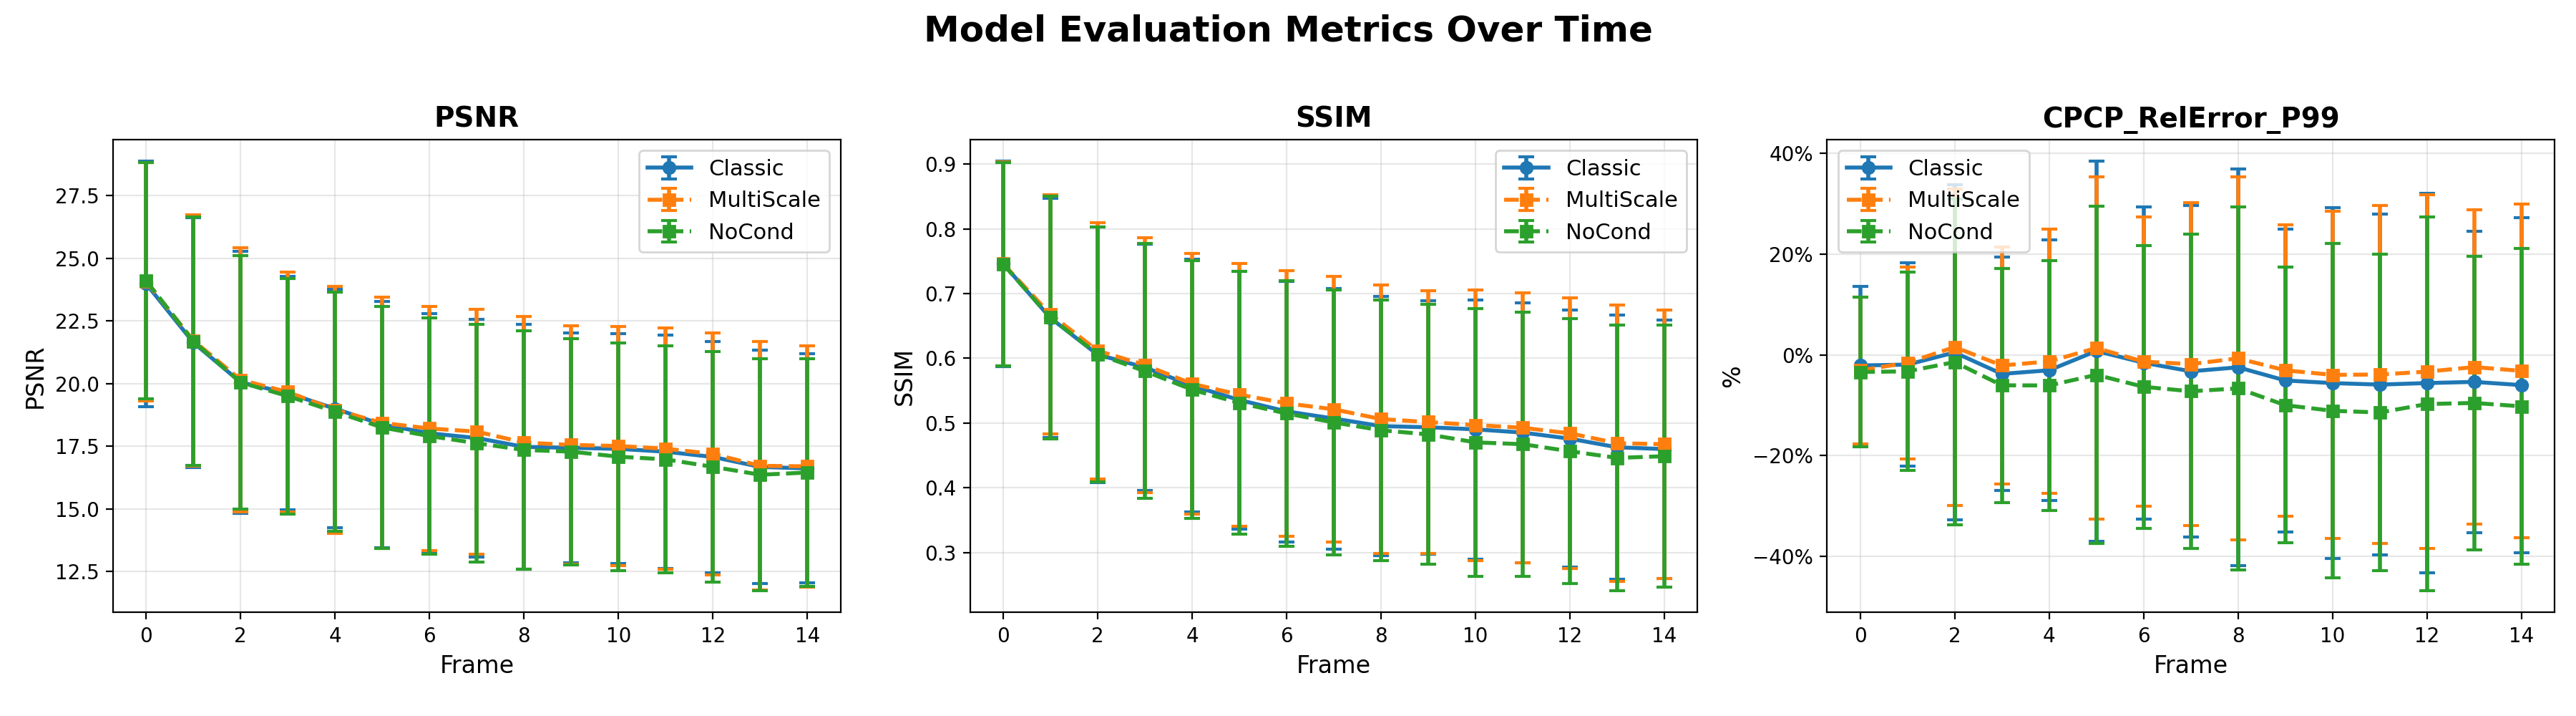

In [4]:
import numpy as np
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from PIL import Image

# ---- Figure setup ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Model Evaluation Metrics Over Time",
    fontsize=18,
    fontweight="bold",
)

x = np.arange(15)

plot_cond = dict(fmt="o-", markersize=6, capsize=4, capthick=1.5, linewidth=2)
plot_other = dict(fmt="s--", markersize=6, capsize=4, capthick=1.5, linewidth=2)

# Only 3 models
models = [
    ("Classic", means_classic, stds_classic, plot_cond),
    ("MultiScale", means_multiscale, stds_multiscale, plot_other),
    ("NoCond", means_nocond, stds_nocond, plot_other),
]

# Only 3 metrics
metrics = ["PSNR", "SSIM", "CPCP_RelError_P99"]

# Metrics that should be shown as percentages
percent_metrics = {"CPCP_RelError_P99"}

# ---- Plot each metric ----
for i, metric in enumerate(metrics):
    ax = axes[i]

    for label, means, stds, style in models:
        y = means[metric]
        yerr = stds[metric]

        if metric in percent_metrics:
            y = y * 100
            yerr = yerr * 100

        ax.errorbar(x, y, yerr=yerr, label=label, **style)

    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_xlabel("Frame", fontsize=12)
    ax.grid(alpha=0.3)

    if metric in percent_metrics:
        ax.set_ylabel("%", fontsize=12)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    else:
        ax.set_ylabel(metric, fontsize=12)

    ax.legend(fontsize=11, loc="best")

# ---- Layout, save, display ----
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig("selected_metrics.png", dpi=200)
plt.close()

Image.open("selected_metrics.png")

In [17]:
from collections import defaultdict
import numpy as np
import ast

results = {
    metric: {
        'classic': defaultdict(list),
        'classic_nomean': defaultdict(list),
        'adaptive': defaultdict(list),
        'multiscale': defaultdict(list),
        'nocond': defaultdict(list),
    }
    for metric in metrics
}

# ------------------------------------------------------
# Classic Embeddings
# ------------------------------------------------------
for idx in range(len(df_classic_emb)):
    for metric in metrics:
        vals = np.array(ast.literal_eval(df_classic_emb[metric].iloc[idx])).reshape(15, 20)
        results[metric]['classic']['early'].append(vals[0:5].mean())
        results[metric]['classic']['mid'].append(vals[5:10].mean())
        results[metric]['classic']['late'].append(vals[10:15].mean())

# ------------------------------------------------------
# Classic Embeddings (No Mean)
# ------------------------------------------------------
for idx in range(len(df_classic_emb_no_mean)):
    for metric in metrics:
        vals = np.array(ast.literal_eval(df_classic_emb_no_mean[metric].iloc[idx])).reshape(15, 20)
        results[metric]['classic_nomean']['early'].append(vals[0:5].mean())
        results[metric]['classic_nomean']['mid'].append(vals[5:10].mean())
        results[metric]['classic_nomean']['late'].append(vals[10:15].mean())

# ------------------------------------------------------
# Adaptive Embeddings
# ------------------------------------------------------
for idx in range(len(df_adaptive_emb)):
    for metric in metrics:
        vals = np.array(ast.literal_eval(df_adaptive_emb[metric].iloc[idx])).reshape(15, 20)
        results[metric]['adaptive']['early'].append(vals[0:5].mean())
        results[metric]['adaptive']['mid'].append(vals[5:10].mean())
        results[metric]['adaptive']['late'].append(vals[10:15].mean())

# ------------------------------------------------------
# Multiscale Embeddings
# ------------------------------------------------------
for idx in range(len(df_multiscale)):
    for metric in metrics:
        vals = np.array(ast.literal_eval(df_multiscale[metric].iloc[idx])).reshape(15, 20)
        results[metric]['multiscale']['early'].append(vals[0:5].mean())
        results[metric]['multiscale']['mid'].append(vals[5:10].mean())
        results[metric]['multiscale']['late'].append(vals[10:15].mean())

# ------------------------------------------------------
# No Conditioning
# ------------------------------------------------------
for idx in range(len(df_nocond)):
    for metric in metrics:
        vals = np.array(ast.literal_eval(df_nocond[metric].iloc[idx])).reshape(15, 20)
        results[metric]['nocond']['early'].append(vals[0:5].mean())
        results[metric]['nocond']['mid'].append(vals[5:10].mean())
        results[metric]['nocond']['late'].append(vals[10:15].mean())

interval_names = {
    'early': 'Interval 1 (0–5)',
    'mid': 'Interval 2 (5–10)',
    'late': 'Interval 3 (10–15)',
}

model_order = [
    ('classic', 'Classic'),
    ('classic_nomean', 'Classic NoMean'),
    ('adaptive', 'Adaptive'),
    ('multiscale', 'MultiScale'),
    ('nocond', 'NoCond'),
]

for metric in metrics:
    print(f"\n{'='*95}")
    print(f"  {metric}")
    print(f"{'='*95}")

    header = f"{'Interval':<20}"
    for _, name in model_order:
        header += f"{name:<25}"
    print(header)
    print("-" * 95)

    for key in ['early', 'mid', 'late']:
        row = f"{interval_names[key]:<20}"
        for model_key, _ in model_order:
            vals = np.array(results[metric][model_key][key])
            row += f"{vals.mean():.4e} ± {vals.std():.4e}".ljust(25)
        print(row)



  PSNR
Interval            Classic                  Classic NoMean           Adaptive                 MultiScale               NoCond                   
-----------------------------------------------------------------------------------------------
Interval 1 (0–5)    2.0858e+01 ± 3.4740e+00  2.0976e+01 ± 3.5976e+00  2.0610e+01 ± 3.4355e+00  2.0911e+01 ± 3.4695e+00  2.0844e+01 ± 3.4181e+00  
Interval 2 (5–10)   1.7822e+01 ± 3.6432e+00  1.7915e+01 ± 3.7374e+00  1.7671e+01 ± 3.4786e+00  1.7982e+01 ± 3.7487e+00  1.7680e+01 ± 3.4606e+00  
Interval 3 (10–15)  1.7005e+01 ± 3.4294e+00  1.7059e+01 ± 3.5556e+00  1.6729e+01 ± 3.4029e+00  1.7102e+01 ± 3.7348e+00  1.6707e+01 ± 3.2326e+00  

  SSIM
Interval            Classic                  Classic NoMean           Adaptive                 MultiScale               NoCond                   
-----------------------------------------------------------------------------------------------
Interval 1 (0–5)    6.3151e-01 ± 1.4082e-01  6.3775e-01 ± 1.43